### Attention Map

By. 1. https://github.com/jacobgil/vit-explain
   2. https://hongl.tistory.com/234

In [10]:
import torch
import timm
import numpy as np
from torchvision import transforms
from PIL import Image

In [11]:
model = torch.hub.load('facebookresearch/deit:main', 
'deit_tiny_patch16_224', pretrained=True)
model = model.cuda()

Using cache found in /home/qkboo/.cache/torch/hub/facebookresearch_deit_main


In [12]:
# [Issue]: result = torch.eye(attentions[0].size(-1)) problem #23 
#  Vit 구조 변경으로 인한 아래 코드 실행
for block in model.blocks:
    block.attn.fused_attn = False

In [18]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std = [0.5, 0.5, 0.5])
])

img = Image.open('dogcat.jpeg')
img = img.resize((224,224))

input_tensor = transform(img).unsqueeze(0)
input_tensor = input_tensor.cuda()

In [19]:
class VITAttentionRollout:
    def __init__(self, model, attention_layer_name='attn_drop', head_fusion="mean", discard_ratio=0.9):
        self.model = model
        self.head_fusion = head_fusion
        self.discard_ratio = discard_ratio
        for name, module in self.model.named_modules():
            if attention_layer_name in name:
                # print(name)
                # print(module.__class__.__name__)
                module.register_forward_hook(self.get_attention)

        self.attentions = []

    def get_attention(self, module, input, output):
        print(f"[HOOK] module: {module.__class__.__name__}, output shape: {output.shape}")
        self.attentions.append(output.cpu())

    def __call__(self, input_tensor):
        self.attentions = []
        with torch.no_grad():
            output = self.model(input_tensor)
        print(f"Collected {len(self.attentions)} attention maps")
        return rollout(self.attentions, self.discard_ratio, self.head_fusion)

In [20]:
def rollout(attentions, discard_ratio, head_fusion):
    '''
    attentions: (1, 3, 197, 197) 크기의 텐서가 12개 담김
    '''
    result = torch.eye(attentions[0].size(-1))
    with torch.no_grad():
        for attention in attentions:
            if head_fusion == "mean":
                attention_heads_fused = attention.mean(axis=1)
            elif head_fusion == "max":
                attention_heads_fused = attention.max(axis=1)[0]
            elif head_fusion == "min":
                attention_heads_fused = attention.min(axis=1)[0]
            else:
                raise "Attention head fusion type Not supported"

            # Drop the lowest attentions, but
            # don't drop the class token
            flat = attention_heads_fused.view(attention_heads_fused.size(0), -1)
            _, indices = flat.topk(int(flat.size(-1) * discard_ratio), dim=-1, largest=False)
            indices = indices[indices != 0]
            flat[0, indices] = 0

            I = torch.eye(attention_heads_fused.size(-1))
            a = (attention_heads_fused + 1.0 * I) / 2
            a = a / a.sum(dim=-1)

            result = torch.matmul(a, result)  # [1, 197, 197]

    # Look at the total attention between the class token,
    # and the image patches
    mask = result[0, 0, 1:]  # [196]
    width = int(mask.size(-1) ** 0.5)
    mask = mask.reshape(width, width).numpy()
    mask = mask / np.max(mask)
    return mask  # [14, 14]


In [21]:
roll_out = VITAttentionRollout(model,head_fusion="mean", discard_ratio=0.9)

In [22]:
mask = roll_out(input_tensor)

[HOOK] module: Dropout, output shape: torch.Size([1, 3, 197, 197])
[HOOK] module: Dropout, output shape: torch.Size([1, 3, 197, 197])
[HOOK] module: Dropout, output shape: torch.Size([1, 3, 197, 197])
[HOOK] module: Dropout, output shape: torch.Size([1, 3, 197, 197])
[HOOK] module: Dropout, output shape: torch.Size([1, 3, 197, 197])
[HOOK] module: Dropout, output shape: torch.Size([1, 3, 197, 197])
[HOOK] module: Dropout, output shape: torch.Size([1, 3, 197, 197])
[HOOK] module: Dropout, output shape: torch.Size([1, 3, 197, 197])
[HOOK] module: Dropout, output shape: torch.Size([1, 3, 197, 197])
[HOOK] module: Dropout, output shape: torch.Size([1, 3, 197, 197])
[HOOK] module: Dropout, output shape: torch.Size([1, 3, 197, 197])
[HOOK] module: Dropout, output shape: torch.Size([1, 3, 197, 197])
[HOOK] module: Dropout, output shape: torch.Size([1, 3, 197, 197])
[HOOK] module: Dropout, output shape: torch.Size([1, 3, 197, 197])
[HOOK] module: Dropout, output shape: torch.Size([1, 3, 197, 1

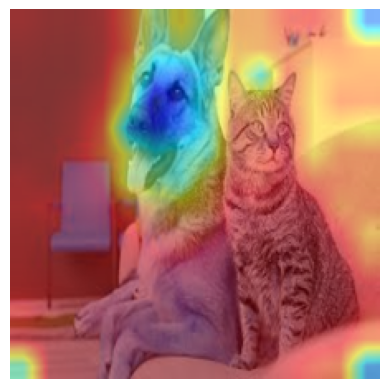

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_mask_on_image(img, mask):
    img = np.float32(img) / 255
    heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    cam = heatmap + np.float32(img)
    cam = cam / np.max(cam)
    return np.uint8(255 * cam)

np_img = np.array(img)[:, :, ::-1]
mask = cv2.resize(mask, (np_img.shape[1], np_img.shape[0]))
mask = show_mask_on_image(np_img, mask)
plt.imshow(mask)
plt.axis('off')  # 축 제거 (선택)
plt.show()